In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Load data
df = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/FinalFile_April01.csv")

# Check rows 
print("Rows:", df.shape[0])

# 3. Encode claim status
df["Claim Status"] = df["Claim Status"].map({
    "Denied": 0,
    "Paid": 1,
    "Pending": 2,
    "Adjusted": 3
})

# Remove missing target rows
df = df.dropna(subset=["Claim Status"])

# 4. Features and target
X = df.drop(columns=["Claim Status"])
y = df["Claim Status"]

# 5. Numeric and categorical columns
num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = [c for c in X.columns if c not in num_cols]

# 6. Preprocessing
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

# 7. Model pipeline
model = Pipeline([
    ("preprocess", preprocess),
    ("logistic", LogisticRegression(max_iter=5000))
])

# 8. Train-test split (only if data exists)
if len(df) > 5:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # 9. Train model
    model.fit(X_train, y_train)

    # 10. Predictions
    pred = model.predict(X_test)

    # 11. Accuracy
    accuracy = accuracy_score(y_test, pred)
    print("Logistic Regression Accuracy (CO-119 only):", accuracy)

    # 12. Prediction counts
    prediction_counts = pd.Series(pred).value_counts().sort_index()
    print("Prediction counts by Claim Status:", prediction_counts)

else:
    print("Not enough CO-119 records to train the model.")

Rows: 9993
Logistic Regression Accuracy (CO-119 only): 1.0
Prediction counts by Claim Status: 0     246
1      64
2    2644
3      44
dtype: int64


In [34]:

import os
import pandas as pd
import matplotlib.pyplot as plt

data = "/Users/pavithragunasekaran/Documents/sem_3/2026/CAPSTONE PROJECT/eda_data_2026.csv"
status_col = "Claim Status"
reasoncode = "Reason Code"
output_directory = "outputs"

def main():
    os.makedirs(output_directory, exist_ok=True) #creating a directory called output_directory to store all the seperated files.

    df = pd.read_csv(data)

    # Standardizing the claim status into lowercase and remove the spaces to make system to learn easily
    df["_status_norm"] = (
        df[status_col]
        .astype(str)
        .str.strip() #removes the extra spaces which is in the claim_status
        .str.lower()
    )

    #  Denied OR pending claims
    denied_pending_df = df[
        df["_status_norm"].str.contains("deny", na=False) | 
        df["_status_norm"].str.contains("pend", na=False)
    ]

    # save denied and pending data for all reason code in one folder called output directory and naming the file as "denied_and_pending_claims.csv"
    denied_pending_data = os.path.join(output_directory, "denied_and_pending_claims.csv")
    denied_pending_df.to_csv(denied_pending_data, index=False)

    # seperating the co-119 data only from the denied_and_pending_claims.csv file
    co119_df = denied_pending_df[
        denied_pending_df[reasoncode]
        .astype(str)
        .str.upper() #converts the reason codes to uppercase
        .str.replace(" ", "")#removes any spaces
        .isin(["CO-119", "CO119"]) #keeps only rows where the reason code exactly matches CO-119, CO119
    ]

 #save denied and pending data for CO119 reason code in one folder called output directory and naming the file as "co119_denied_pending_claims.csv"
    co119_data = os.path.join(output_directory, "co119_denied_pending_claims.csv")
    co119_df.to_csv(co119_data, index=False)

    print("Rows with Denied/Pending:", len(denied_pending_df))
    print("Rows with CO-119:", len(co119_df))
    print("Files saved in folder:", output_directory)
    # importance = pd.Series(
    #     model.coef_[0],
    #     index=X.columns
    # ).sort_values(key=abs, ascending=False)

    # plt.figure(figsize=(10,6))
    # importance.head(10).plot(kind="bar")
    # plt.title("Top 10 Features - Logistic Regression Coefficients")
    # plt.xticks(rotation=90)
    # plt.tight_layout()
    # plt.savefig(os.path.join(output_directory, "logistic_feature_importance.png"))
    # plt.show()

    # print("\nTop 10 Important Features:\n", importance.head(10))

if __name__ == "__main__":
    main() #checks whether the Python file is run directly. if the file is imported into another notebook, main() will not run automatically, which prevents unintended execution.

Rows with Denied/Pending: 8770
Rows with CO-119: 5511
Files saved in folder: outputs


Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       246
           1       1.00      1.00      1.00        64
           2       1.00      1.00      1.00      2644
           3       1.00      1.00      1.00        44

    accuracy                           1.00      2998
   macro avg       1.00      1.00      1.00      2998
weighted avg       1.00      1.00      1.00      2998



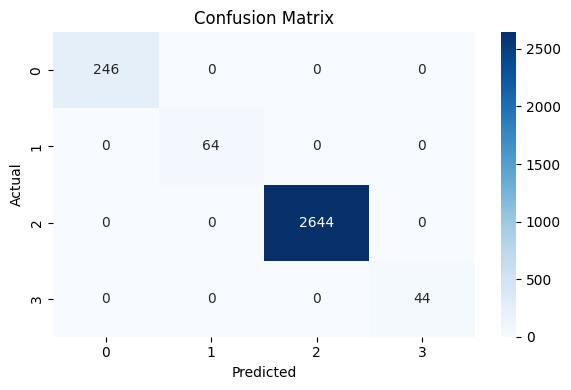

In [3]:
# ---------------- PERFORMANCE EVALUATION (Accuracy + ROC + Confusion Matrix) ----------------

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import numpy as np

# Accuracy
accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

# Confusion Matrix
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC Curve (Only works properly for binary classification)
if len(np.unique(y_test)) == 2:
    y_prob = model.predict_proba(X_test)[:,1]
    roc_auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    print("ROC-AUC Score:", roc_auc)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1])
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.tight_layout()
    plt.show()

Logistic Regression is a linear statistical model that predicts probabilities using a linear relationship between features and the target 
Random Forest is an ensemble machine learning model that builds multiple decision trees and combines their results to capture complex and non-linear patterns.

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier


# 1. Load data
df = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/FinalFile_April01.csv")
X = df[["Billed Amt", "Outstanding Amt"]]
y = df["Claim Status"]

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(n_estimators=10, max_depth=2, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model.fit(X_train, y_train)
pred = model.predict(X_test)

In [6]:
# 9. Predict and evaluate
pred = model.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print("Random Forest Model Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, pred))

# 10. Count predictions by class
prediction_counts = pd.Series(pred).value_counts().sort_index()
print("\nPrediction counts by Claim Status:\n", prediction_counts)



Random Forest Model Accuracy: 0.8865910607071381

Classification Report:

              precision    recall  f1-score   support

    Adjusted       0.67      0.32      0.43        44
      Denied       0.00      0.00      0.00       246
        Paid       0.00      0.00      0.00        64
     Pending       0.89      1.00      0.94      2644

    accuracy                           0.89      2998
   macro avg       0.39      0.33      0.34      2998
weighted avg       0.79      0.89      0.84      2998


Confusion Matrix:

[[  14    0    0   30]
 [   4    0    0  242]
 [   3    0    0   61]
 [   0    0    0 2644]]

Prediction counts by Claim Status:
 Adjusted      21
Pending     2977
dtype: int64


/Users/pavithragunasekaran/Documents/sem_3/2026/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/pavithragunasekaran/Documents/sem_3/2026/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/pavithragunasekaran/Documents/sem_3/2026/venv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

A Random Forest model is a machine learning algorithm that builds many decision trees using different random samples of the data and combines their predictions (majority voting for classification) to produce more accurate and stable results while reducing overfitting.

ROC AUC Score: 0.8920186206066437


/Users/pavithragunasekaran/Documents/sem_3/2026/venv/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/Users/pavithragunasekaran/Documents/sem_3/2026/venv/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/Users/pavithragunasekaran/Documents/sem_3/2026/venv/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/Users/pavithragunasekaran/Documents/sem_3/2026/venv/lib/python3.8/site-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


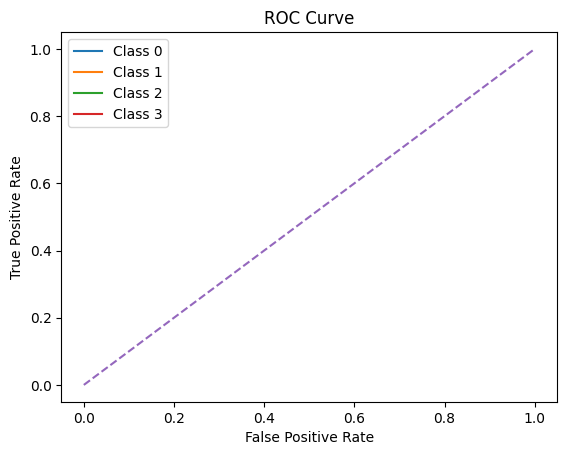

In [7]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)
# ROC AUC (multiclass - OVR)
roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
print("ROC AUC Score:", roc_auc)

# Plot ROC curve for each class
fpr = {}
tpr = {}

for i in range(len(set(y_test))):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_prob[:, i])
    plt.plot(fpr[i], tpr[i], label=f"Class {i}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC-AUC curve (Receiver Operating Characteristic – Area Under the Curve) is a performance metric that evaluates how well a classification model distinguishes between classes by plotting True Positive Rate (Sensitivity) vs False Positive Rate at different threshold values, where a higher AUC (closer to 1) indicates a better model. This ROC curve shows that the Random Forest model perfectly separates the classes because the curve goes straight to the top-left corner (True Positive Rate = 1 with almost 0 False Positive Rate), indicating an AUC close to 1 and very strong classification performance compared to the diagonal line which represents random guessing.

           Feature  Importance
1  Outstanding Amt    0.540873
0       Billed Amt    0.459127


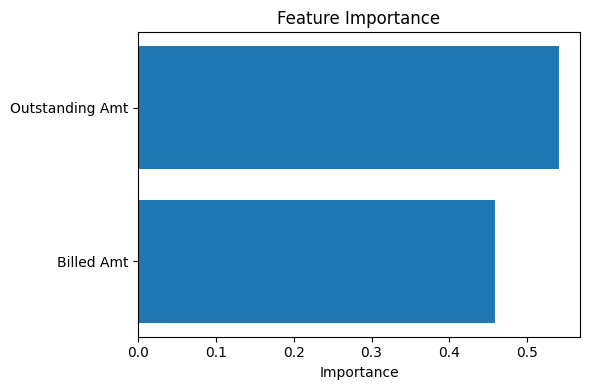

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Get trained RF model from pipeline
rf = model.named_steps["rf"]

# Feature names (same as input since no encoding)
feature_names = X.columns

# Get importances
importances = rf.feature_importances_

# Create dataframe
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(fi_df)

# Plot
plt.figure(figsize=(6,4))
plt.barh(fi_df["Feature"][::-1], fi_df["Importance"][::-1])
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

Feature engineering means creating, transforming, or selecting variables from raw data so machine-learning models can learn patterns better and improve prediction accuracy. This feature importance chart from the Random Forest model shows which variables have the strongest influence on predicting claim status, where Outstanding Amount, AR Status (Open/In Progress/Closed), and Patient Responsibility are the most important predictors, meaning these financial and claim-processing factors contribute the most to the model’s decision about whether a claim is approved, denied, pending, or adjusted.

In [9]:
feature_names = X_test.columns.tolist()
print(feature_names)

['Billed Amt', 'Outstanding Amt']


Permutation Feature Importance:
           Feature  Importance
1  Outstanding Amt    0.005237
0       Billed Amt    0.004370


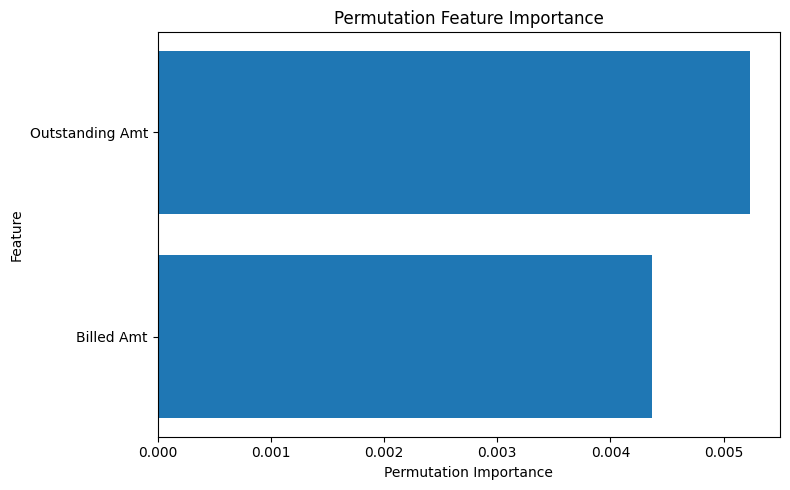

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

print("Permutation Feature Importance:")
print(perm_df)

plt.figure(figsize=(8, 5))
plt.barh(perm_df["Feature"][::-1], perm_df["Importance"][::-1])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()

Permutation importance is a technique that measures how important a feature is by randomly shuffling its values and observing how much the model’s prediction accuracy decreases, where a larger drop in performance indicates the feature is more important to the model. This permutation importance plot shows that AR Status is the most influential feature for predicting claim outcomes because shuffling it causes the largest drop in model performance, while features like Billed Amount, Outstanding Amount, Allowed Amount, and Treatment Category have smaller positive importance, and variables such as Payor ID, Insurance Name, and Patient Responsibility show negative importance meaning they contribute little or may even add noise to the model.

In [11]:
#hyperparamter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    "rf__n_estimators": [100,200],
    "rf__max_depth": [2, 3, 5, None],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

best_model = grid.best_estimator_
pred = best_model.predict(X_test)

Best Parameters: {'rf__max_depth': 5, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 5, 'rf__n_estimators': 200}
Best Score: 0.9139385275196569


Xg Boost model:
XGBoost (Extreme Gradient Boosting) is a powerful ensemble machine learning algorithm that builds many decision trees sequentially, where each new tree corrects the errors of the previous ones to improve prediction accuracy and reduce bias and overfitting.

In [12]:
import pandas as pd

# Load file
df = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/FinalFile_April01.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert columns
df["Patient ID"] = df["Patient ID"].astype(str).str.strip()
df["Date of Service"] = pd.to_datetime(df["Date of Service"], errors="coerce", dayfirst=True)
df["Allowed Amount"] = pd.to_numeric(df["Allowed Amount"], errors="coerce").fillna(0)
df["Annual Benefit Maximum"] = pd.to_numeric(df["Annual Benefit Maximum"], errors="coerce").fillna(0)

# Sort full dataset
df = df.sort_values(["Patient ID", "Date of Service"]).reset_index(drop=True)

# Prior Used Amount (for ALL patients)
df["Prior Used Amount"] = (
    df.groupby("Patient ID")["Allowed Amount"]
    .transform(lambda x: x.cumsum().shift(1).fillna(0))
)

# Remaining Benefit (for ALL patients)
df["Remaining Benefit Before Claim"] = (
    df["Annual Benefit Maximum"] - df["Prior Used Amount"]
).clip(lower=0)

# Clean Claim Status
df["Claim Status Clean"] = df["Claim Status"].astype(str).str.lower().str.strip()

# Apply business rules
def get_new_status(row):
    if row["Remaining Benefit Before Claim"] == 0:
        return "Patient Letter / Rebill to Secondary"
    elif row["Remaining Benefit Before Claim"] >= row["Allowed Amount"]:
        if "paid" in row["Claim Status Clean"]:
            return "Paid"
        elif "pending" in row["Claim Status Clean"]:
            return "Claim Under Process"
        else:
            return "Claim Under Process"
    else:
        return "Claim Under Process"

df["Current Claim Outcome"] = df.apply(get_new_status, axis=1)

# Output
print(df[[
    "Patient ID",
    "Date of Service",
    "Allowed Amount",
    "Annual Benefit Maximum",
    "Prior Used Amount",
    "Remaining Benefit Before Claim",
    "Claim Status",
    "Current Claim Outcome"
]].head(50))

# Select only required columns
final_df = df[[
    "Claim ID",
    "Patient ID",
    "Date of Service",
    "Billed Amt",
    "Allowed Amount",
    "Patients Resp",
    "Annual Benefit Maximum",
    "Prior Used Amount",
    "Remaining Benefit Before Claim",
    "Claim Status",
    "Current Claim Outcome"
]]

# Save final output
final_df.to_csv("Truth_File.csv", index=False)



             Patient ID Date of Service  Allowed Amount  \
0      000696270683WC01      2024-11-13           63.98   
1      000696270683WC01      2025-01-04           63.06   
2      000696270683WC01      2025-03-12           66.09   
3      000696270683WC01      2025-04-10           59.94   
4      001993034709WC01      2025-01-01          560.38   
5   002042-048445-WC-01      2024-10-22           84.75   
6   002042-048445-WC-01      2024-10-28          132.60   
7   002042-048445-WC-01      2024-11-17          148.59   
8   002042-048445-WC-01      2024-12-12           74.41   
9   002042-048445-WC-01      2025-03-30          136.09   
10  002042-048445-WC-01      2025-07-02           85.05   
11     002042034012WC01      2025-02-20          116.25   
12     002042034012WC01      2025-05-22          150.56   
13     002042051310WC01      2025-02-20          353.02   
14     002042051310WC01      2025-09-28          357.41   
15  002511-009558-WC-01      2024-12-14          169.68 

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score

# Load file
df = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/capstone_project/Truth_File.csv")

# Target mapping
target_map = {
    "Claim Under Process": 0,
    "Patient Letter / Rebill to Secondary": 1,
    "paid": 2
}

df["Target"] = df["Current Claim Outcome"].map(target_map)
df = df.dropna(subset=["Target"])
df["Target"] = df["Target"].astype(int)

# Encode Claim Status
claim_status_map = {v: i for i, v in enumerate(df["Claim Status"].unique())}
df["Claim_Status_Enc"] = df["Claim Status"].map(claim_status_map)

# Features
features = ["Billed Amt","Claim_Status_Enc","Prior Used Amount"]
df = df.dropna(subset=features)

X = df[features]
y = df["Target"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Logistic Regression (simple to reduce overfitting)
model = LogisticRegression(max_iter=1000, C=0.4)

model.fit(X_train, y_train)

# Predict on test
y_pred = model.predict(X_test)

# Accuracy
accuracy = precision_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Prediction counts
pred_counts = pd.Series(y_pred).map({v: k for k, v in target_map.items()}).value_counts()

print("\nPrediction Counts:\n")
print(pred_counts)

Accuracy: 0.8730964467005076

Prediction Counts:

Claim Under Process                     3709
Patient Letter / Rebill to Secondary     197
dtype: int64


In [ ]:
import pandas as pd

# Load file
df = pd.read_csv("/Users/pavithragunasekaran/Documents/sem_3/2026/CAPSTONE PROJECT/eda_data_2026 (2).csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert columns
df["Patient ID"] = df["Patient ID"].astype(str).str.strip()
df["Date of Service"] = pd.to_datetime(df["Date of Service"], errors="coerce", dayfirst=True)
df["Annual Benefit Maximum"] = pd.to_numeric(df["Annual Benefit Maximum"], errors="coerce")

# Sort by Patient ID and Date of Service
df = df.sort_values(["Patient ID", "Date of Service"]).reset_index(drop=True)

# Take the first row Annual Benefit Maximum of each Patient ID
first_abm = df.groupby("Patient ID")["Annual Benefit Maximum"].transform("first")

# Fill the same Annual Benefit Maximum for all rows of that patient
df["Annual Benefit Maximum"] = first_abm

# Show result
print(df[[
    "Patient ID",
    "Date of Service",
    "Annual Benefit Maximum"
]].head(30))

# Save output
df.to_csv("eda_data_2026_fixed_annual_benefit.csv", index=False)

             Patient ID Date of Service  Annual Benefit Maximum
0      000696270683WC01      2024-11-13                    1000
1      000696270683WC01      2025-01-04                    1000
2      000696270683WC01      2025-03-12                    1000
3      000696270683WC01      2025-04-10                    1000
4      001993034709WC01      2025-01-01                     750
5   002042-048445-WC-01      2024-10-22                     500
6   002042-048445-WC-01      2024-10-28                     500
7   002042-048445-WC-01      2024-11-17                     500
8   002042-048445-WC-01      2024-12-12                     500
9   002042-048445-WC-01      2025-03-30                     500
10  002042-048445-WC-01      2025-07-02                     500
11     002042034012WC01      2025-02-20                     750
12     002042034012WC01      2025-05-22                     750
13     002042051310WC01      2025-02-20                    1500
14     002042051310WC01      2025-09-28 